# **2024(R6)年度 機械学習**
# **第4週　非線形モデルによるクラス分類2**
## 多層パーセプトロン(Multi-Layer Perceptron; MLP)
©️小林 邦和＠愛知県立大学 情報科学部  
Date: October 24, 2023

# **準備**

## 警告の非表示(必要に応じて実行，Google Colabでは不要)

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Google Driveのマウント(必要に応じて実行)

In [2]:
# if str(get_ipython()).startswith("<google.colab."):
#     from google.colab import drive
#     drive.mount('/content/drive')

## 日本語化Matplotlib(必要に応じて実行)

In [3]:
# if str(get_ipython()).startswith("<google.colab."):
#     !pip install japanize-matplotlib

## 各種ライブラリの読み込み

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# グラフ表示で日本語を使う場合，以下2行は必須
# import japanize_matplotlib
# japanize_matplotlib.japanize()

## フラグ設定

In [5]:
# 使用するデータセットのコメントを外し，使用しないものはコメントアウト
data_flag = 0 # ガウス分布状データ
#data_flag = 1 # 三日月状データ
#data_flag = 2 # 同心円状データ

# 使用するMLPモデルの活性化関数のコメントを外し，使用しないものはコメントアウト
# a_func = 'identity' # 活性化関数：恒等関数
a_func = 'logistic' # 活性化関数：シグモイド関数
# a_func = 'tanh' # 活性化関数：双曲線正接関数(tanh)
# a_func = 'relu' # 活性化関数：双曲線正接関数(tanh)

# 使用するMLPモデルの中間層ユニット数のコメントを外し，使用しないものはコメントアウト
#hidden_layer_sizes=(10,)
hidden_layer_sizes=(20,)
#hidden_layer_sizes=(50,)
#hidden_layer_sizes=(20,10)
#hidden_layer_sizes=(50,20)

# **データの準備**

### **ガウス布状N次元データ**
### **make_blobs**
引数
*   n_samples：データの個数
*   n_features：特徴量の数(N)
*   centers：塊の数
*   cluster_std：ばらつきの大きさ(標準偏差)
*   random_state：乱数生成のシード値(同じ値の設定で再現性の確保)

戻り値
*   入力データ(n_samples x n_features)
*   出力データ(n_samples)

## **データの生成と散布図**
特徴量が2種類(2次元)，塊が2個(2クラス)，標準偏差が1の300個のデータセット

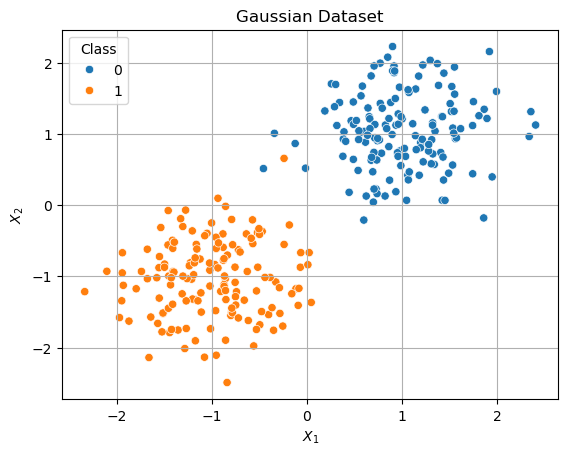

In [6]:
if data_flag == 0:
    from sklearn.datasets import make_blobs

    X, y = make_blobs(
        n_samples=300,
        n_features=2,
        centers=[[1,1],[-1,-1]],
    #    centers=[[1,1],[0,0],[-1,-1]],
    #    centers=2,
    #    centers=3,
        cluster_std=0.5,
    #    cluster_std=0.2,
    #    cluster_std=0.9,
        random_state=3)

    # 特徴量(X)でデータフレームを作成し，クラス(y)をClassの列として追加
    df = pd.DataFrame(X)
    df.rename(columns={0: "X1", 1: "X2"}, inplace=True)
    df["Class"] = y

    # クラス0は青，クラス1は橙で散布図を描画
    sns.scatterplot(x="X1", y="X2", hue="Class", data=df)
    plt.title("Gaussian Dataset")
    # plt.title("ガウス分布状2次元データ")
    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.grid()
    plt.show()

## **三日月状2次元データ**
### **make_moons**
引数
*   n_samples：データの個数
*   noise：ガウスノイズの標準偏差
*   random_state：乱数生成のシード値(同じ値の設定で再現性の確保)

戻り値
*   入力データ(n_samples x 2)
*   出力データ(n_samples)

In [7]:
if data_flag == 1:
    from sklearn.datasets import make_moons

    X, y = make_moons(
        n_samples=300,
        noise=0.1,
        random_state=3)

    # 特徴量（X）でデータフレームを作成し，分類（y）をClassの列として追加
    df = pd.DataFrame(X)
    df.rename(columns={0: "X1", 1: "X2"}, inplace=True)
    df["Class"] = y

    # クラス0は青，クラス1は橙で散布図を描画
    sns.scatterplot(x="X1", y="X2", hue="Class", data=df)
    plt.title("Crescent Dataset")
    # plt.title("三日月状2次元データ")
    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.grid()
    plt.show()

## **同心円状2次元データ**
### **make_circles**
引数
*   n_samples：データの個数
*   noise：ガウスノイズの標準偏差
*   random_state：乱数生成のシード値(同じ値の設定で再現性の確保)

戻り値
*   入力データ(n_samples x 2)
*   出力データ(n_samples)

In [8]:
if data_flag == 2:
    from sklearn.datasets import make_circles

    X, y = make_circles(
        n_samples=300,
        noise = 0.1,
        random_state=3)

    # 特徴量（X）でデータフレームを作成し，分類（y）をClassの列として追加
    df = pd.DataFrame(X)
    df.rename(columns={0: "X1", 1: "X2"}, inplace=True)
    df["Class"] = y

    # クラス0は青，クラス1は橙で散布図を描画
    sns.scatterplot(x="X1", y="X2", hue="Class", data=df)
    plt.title("Concentric Dataset")
    # plt.title("同心円状2次元データ")
    plt.xlabel("$X_1$")
    plt.ylabel("$X_2$")
    plt.grid()
    plt.show()

# **データの分割(訓練用とテスト用)**
### **train_test_split**
引数
*   test_size：テストデータのサイズ指定(0〜1.0)
*   train_size：訓練データのサイズ指定(0〜1.0)
*   random_state：乱数生成のシード値

戻り値
*   X_train：訓練用入力データ
*   y_train：訓練用出力データ
*   X_test：テスト用入力データ
*   y_test：テスト用出力データ

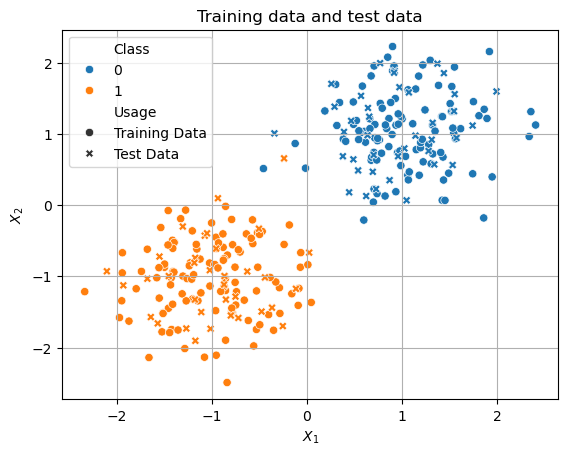

In [9]:
# 訓練データとテストデータへ分割
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 訓練用の特徴量(X_train)でデータフレームを作成し，クラス(y_train)をClassの列として追加
df_train = pd.DataFrame(X_train)
df_train.rename(columns={0: "X1", 1: "X2"}, inplace=True)
df_train["Class"] = y_train
df_train["Usage"] = "Training Data"

# テスト用の特徴量(X_test)でデータフレームを作成し，クラス(y_test)をClassの列として追加
df_test = pd.DataFrame(X_test)
df_test.rename(columns={0: "X1", 1: "X2"}, inplace=True)
df_test["Class"] = y_test
df_test["Usage"] = "Test Data"

# 訓練用とテスト用のデータを結合
df = pd.concat([df_train, df_test])

# クラス0は青，クラス1は橙，訓練用はO，テスト用はXで散布図を描画
sns.scatterplot(x="X1", y="X2", hue="Class", style="Usage", data=df)
plt.title("Training data and test data")
# plt.title("訓練データとテストデータ")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.grid()
plt.show()

# **モデルの学習**
### **階層型ニューラルネットワーク**
### **MLPClassifier** 多層パーセプトロンのクラス
引数
*   hidden_layer_sizes：中間層のユニット数と層数  
    例1: (20,10)の場合，中間層2層構造で第1と第2中間層のユニット数がそれぞれ20個，10個  
    例2: (10,20,10)の場合，中間層3層構造で第1，第2，第3中間層のユニット数がそれぞれ10個，20個，10個
*   activation：ユニットの活性化関数
    *   恒等写像‘identity’
    *   シグモイド関数‘logistic’
    *   双曲線正接関数‘tanh’
    *   正規化線形関数‘relu’

**fit**  モデルの訓練のための関数(メソッド)  
引数
*   X：入力データ
*   y：出力データ

In [10]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation=a_func)
print("活性化関数：{0:s}".format(a_func))

# 訓練データを用いた学習
model.fit(X_train, y_train)

活性化関数：logistic


MLPClassifier(activation='logistic', hidden_layer_sizes=(20,))

# **学習済みモデルのテスト**
### **predict**  学習済モデルのテストのための関数(メソッド)  
引数
*   y：出力データ

戻り値
*   予測値

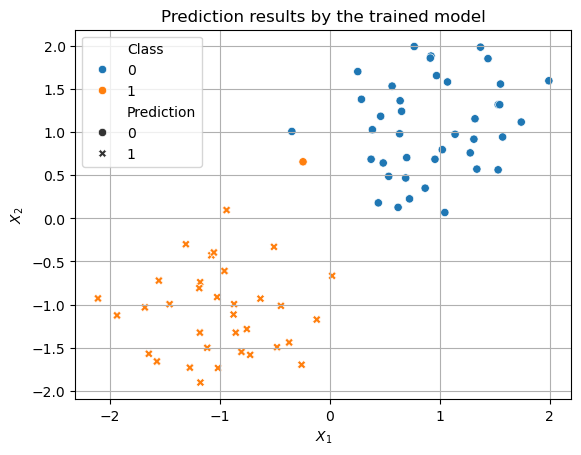

In [11]:
# テストデータを用いた予測
pred_test = model.predict(X_test)

# クラスの予測結果(pred_test)をPredictionの列として追加
df_test["Prediction"] = pred_test

# 正解のクラス0は青，クラス1は橙，予測のクラス0はO，クラス1はXで散布図を描画
sns.scatterplot(x="X1", y="X2", hue="Class", style="Prediction", data=df_test)
plt.title("Prediction results by the trained model")
#plt.title("学習済モデルの予測結果")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.grid()
plt.show()

# **モデルの性能評価**

## **正解率の計算**
### **accuracy_score**
引数
*   X：テスト用入力データ
*   y：テスト用出力データ

戻り値
*   正解率

In [12]:
from sklearn.metrics import accuracy_score

# 正解率の計算(テストデータ)
score = accuracy_score(y_test, pred_test)
print("正解率 = {0:5.1f}%".format(score*100))

正解率 =  98.7%


## **混同行列の計算**
### **accuracy_score**
引数
*   y：正解値
*   pred：予測値

戻り値
*   混同行列

In [13]:
from sklearn.metrics import confusion_matrix

# 混同行列の計算(テストデータ)
print("混同行列=\n{0}".format(confusion_matrix(y_test, pred_test)))

混同行列=
[[40  0]
 [ 1 34]]


## **決定境界の描画**
### **plot_boundary**
引数
*   clf：モデル
*   X：第1特徴量
*   Y：第2特徴量
*   target：予測値
*   xlabel：横軸のラベル
*   ylabel：縦軸のラベル

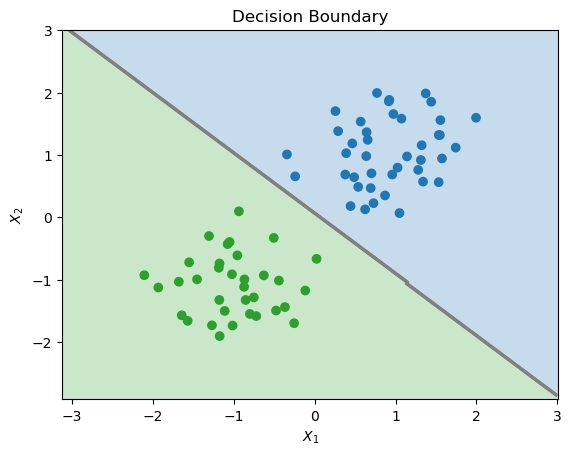

In [14]:
# 散布図に決定境界を描画する関数
from matplotlib.colors import ListedColormap
def plot_boundary(model, X, Y, target, xlabel, ylabel):
    # 点と塗り潰しのカラーマップ
    cmap_dots = ListedColormap([ "#1f77b4", "#ff7f0e", "#2ca02c"])
    cmap_fills = ListedColormap([ "#c6dcec", "#ffdec2", "#cae7ca"])

    # モデルがあれば，表示範囲の点をすべて予測して色を塗る
    if model:
        # 表示範囲を少し広げて分割し，調べる点(200x200)を用意
        XX, YY = np.meshgrid(
            np.linspace(X.min()-1, X.max()+1, 200),
            np.linspace(Y.min()-1, Y.max()+1, 200))
        # すべての点の値をモデルで予測
        pred = model.predict(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
        #　予測結果の値(0〜2)の色(cmap_fills)で塗りつぶす
        plt.pcolormesh(XX, YY, pred, cmap=cmap_fills, shading="auto")
        #　境界を灰色で塗る
        plt.contour(XX, YY, pred, colors="gray")
    #　targetの値(0〜2)の色(cmap_dots)で点を描画
    plt.scatter(X, Y, c=target, cmap=cmap_dots)
    plt.title("Decision Boundary")
    # plt.title("決定境界")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# 決定境界の描画
plot_boundary(model, df_test["X1"], df_test["X2"], pred_test, "$X_1$", "$X_2$")